# QF 627 Programming and Computational Finance
## Lesson 01 | Revisit NumPy, Pandas, Matplotlib, Bokeh, Seaborn, and lets-plot

> Now that you are sufficinetly familiar with the basics of data cleaning and analysis in pandas, we're going to take it up a notch. 

> Previously, the datasets were in relatively clean and straightforward formats. 

> However, in many cases, the data you analyze can be extremely messy and difficult to manage.

> That's why we're going to practice with a more unweildy. 

> You'll notice that it's quite a big file – about 1.7 million rows! 

> These are reports from accidents in New Jersey between 2008 and 2013 from the New Jersey Department of Transportation. 

> The data was scraped from [PDFs of crash reports](http://www.state.nj.us/transportation/refdata/accident/) filled out by clerk.

### Import pandas and let's load in our new and very messy data

In [1]:
import pandas as pd

In [2]:
accidents = pd.read_csv("accidents.csv", 
                        encoding = "ISO-8859-1")

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_21010/809867518.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  accidents = pd.read_csv("accidents.csv",


> You may notice that you get this warning.

`"DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False. interactivity=interactivity, compiler=compiler, result=result)"`

> This dtype error happens when when a column has both strings and integer values. 

> You can ignore this for now because we'll fix it soon. Open up the first few rows of our dataframe.

In [3]:
accidents.head()

,case code,County Name,Municipality Name,Crash Date,Crash Day Of Week,Crash Time,Police Dept Code,Police Department,Police Station,Total Killed,...,Is Ramp,Ramp To/From Route Name,Ramp To/From Route Direction,Posted Speed,Posted Speed Cross Street,Latitude,Longitude,Cell Phone In Use Flag,Other Property Damage,Reporting Badge No.
0,2008010108-026816,ATLANTIC,ABSECON CITY,3/4/08,TU,1539,1,ATLANTIC CITY,AIU,0,...,,,,50,,39.41158,74.49162,N,NONE ...,384
1,2008010108-163190,ATLANTIC,ABSECON CITY,12/19/08,F,1114,1,ATLANTIC CITY,TRAFFIC,0,...,,,,50,,39.39231,74.48952,N,NONE ...,739
2,2008010108-24779,ATLANTIC,ABSECON CITY,11/25/08,TU,345,99,NJ TRANSIT P.D.,ATLANTIC CITY,0,...,,,,10,25,,,N,? ...,53
3,2008010108-3901,ATLANTIC,ABSECON CITY,3/31/08,M,105,1,EAST WINDSOR,TRAFFIC UNIT,0,...,,,,0,,,,N,NONE ...,551
4,2008010108-5016,ATLANTIC,ABSECON CITY,1/25/08,F,942,1,EGG HARBOR TWP,HQ,0,...,,,,50,40,39.43036,74.52469,N,NONE ...,1571


> Let's found out what we're working with, and get the column headers for all of the columns.

In [4]:
accidents.columns

Index(['case code', ' County Name', ' Municipality Name', ' Crash Date',
       ' Crash Day Of Week', ' Crash Time', ' Police Dept Code',
       ' Police Department', ' Police Station', ' Total Killed',
       ' Total Injured', ' Pedestrians Killed', ' Pedestrians Injured',
       ' Severity', ' Intersection', ' Alcohol Involved', ' HazMat Involved',
       ' Crash Type Code', ' Total Vehicles Involved', ' Crash Location',
       ' Location Direction', ' Route', ' Route Suffix',
       ' SRI (Std Rte Identifier)', ' MilePost  ', ' Road System',
       ' Road Character', ' Road Surface Type', ' Surface Condition',
       ' Light Condition', ' Environmental Condition', ' Road Divided By',
       ' Temporary Traffic Control Zone', ' Distance To Cross Street',
       ' Unit Of Measurement', ' Directn From Cross Street',
       ' Cross Street Name', ' Is Ramp', ' Ramp To/From Route Name',
       ' Ramp To/From Route Direction', ' Posted Speed',
       ' Posted Speed Cross Street', ' Latitud

> Bummer. There's our first problem. Notice that there's a leading space in every column header. We should take it out.

In [5]:
accidents.rename(columns = lambda x: x.strip(), inplace = True) # will address empty spaces on column headers

> Remember where we renamed the columns in our dataframe previously? 

> This time, we're using the same rename function to do take out all of the leading spaces using `strip()`. 

> Pythonistas will notice that we're using the `lambda python` to apply `strip()` to every single column header.

In [6]:
accidents.columns

Index(['case code', 'County Name', 'Municipality Name', 'Crash Date',
       'Crash Day Of Week', 'Crash Time', 'Police Dept Code',
       'Police Department', 'Police Station', 'Total Killed', 'Total Injured',
       'Pedestrians Killed', 'Pedestrians Injured', 'Severity', 'Intersection',
       'Alcohol Involved', 'HazMat Involved', 'Crash Type Code',
       'Total Vehicles Involved', 'Crash Location', 'Location Direction',
       'Route', 'Route Suffix', 'SRI (Std Rte Identifier)', 'MilePost',
       'Road System', 'Road Character', 'Road Surface Type',
       'Surface Condition', 'Light Condition', 'Environmental Condition',
       'Road Divided By', 'Temporary Traffic Control Zone',
       'Distance To Cross Street', 'Unit Of Measurement',
       'Directn From Cross Street', 'Cross Street Name', 'Is Ramp',
       'Ramp To/From Route Name', 'Ramp To/From Route Direction',
       'Posted Speed', 'Posted Speed Cross Street', 'Latitude', 'Longitude',
       'Cell Phone In Use Flag', '

> Good job :)

> Let's describe() the dataframe.

In [7]:
accidents.describe()

,Total Killed,Total Injured,Pedestrians Killed,Pedestrians Injured,Total Vehicles Involved,Road System,Posted Speed
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.965525e-03,3.119510e-01,4.854207e-04,1.735117e-02,1.875997e+00,5.199488e+00,3.120711e+01
std,4.694568e-02,7.015340e-01,2.211335e-02,1.344480e-01,5.416507e-01,2.491480e+00,1.790289e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,2.500000e+01
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,5.000000e+00,2.500000e+01
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,7.000000e+00,4.500000e+01
max,5.000000e+00,4.200000e+01,2.000000e+00,1.000000e+01,2.000000e+01,1.000000e+01,9.900000e+01


> But let's see if we could describe() a column. Let's use the describe() function for the `County Name` column header.

In [8]:
accidents["County Name"].value_counts()

County Name
MIDDLESEX       115760
ESSEX           112580
BERGEN          112521
HUDSON           78693
CAMDEN           64739
MONMOUTH         64637
UNION            59556
PASSAIC          56494
MERCER           55008
OCEAN            53104
MORRIS           49096
BURLINGTON       45010
SOMERSET         36621
ATLANTIC         35130
GLOUCESTER       31940
CUMBERLAND       18876
HUNTERDON        16441
CAPE MAY         13198
SUSSEX           12587
WARREN           11123
SALEM             5461
Name: count, dtype: int64

> So there are 21 unique values in the `County Name` column (for the 21 counties in New Jersey). 

> We can see that the top county with the most rows is Middlesex County with 176,402 crashes. 

> What are the names of the counties in New Jersey? Let's find out by using the unique() function on our `County Name` column.

In [9]:
accidents["County Name"].unique()

array(['ATLANTIC    ', 'BERGEN      ', 'BURLINGTON  ', 'CAMDEN      ',
       'CAPE MAY    ', 'CUMBERLAND  ', 'ESSEX       ', 'GLOUCESTER  ',
       'HUDSON      ', 'HUNTERDON   ', 'MERCER      ', 'MIDDLESEX   ',
       'MONMOUTH    ', 'MORRIS      ', 'OCEAN       ', 'PASSAIC     ',
       'SALEM       ', 'SOMERSET    ', 'SUSSEX      ', 'UNION       ',
       'WARREN      '], dtype=object)

> Looks like we're going to need to strip out the spaces out of the these county values. 

> This time we'll use the `map()` function which will strip the white space out of every string found in the column.

In [10]:
accidents["County Name"] = accidents["County Name"].map(str.strip) # will address empty spaces on each cell
accidents["County Name"].unique()

array(['ATLANTIC', 'BERGEN', 'BURLINGTON', 'CAMDEN', 'CAPE MAY',
       'CUMBERLAND', 'ESSEX', 'GLOUCESTER', 'HUDSON', 'HUNTERDON',
       'MERCER', 'MIDDLESEX', 'MONMOUTH', 'MORRIS', 'OCEAN', 'PASSAIC',
       'SALEM', 'SOMERSET', 'SUSSEX', 'UNION', 'WARREN'], dtype=object)

> `map()` function returns a map object(which is an iterator) of the results after applying the given function to each item of a given iterable (list, tuple etc.)

#### map(function, iterables)

* function : It is a function to which map passes each element of given iterable.
* iterables : It is a iterable which is to be mapped.

> NOTE : You can pass one or more iterable to the map() function.

* Returns a list of the results after applying the given function to each item of a given iterable (list, tuple etc.) 
 
> NOTE : The returned value from map() (map object) then can be passed to functions like list() (to create a list), set() (to create a set) .

In [11]:
def addition(q):
    return q + q

In [12]:
# We double all numbers using map()
numbers = (1, 2, 3, 4)
result = map(addition, numbers)
print(list(result)
     )

[2, 4, 6, 8]


> You can also use lambda expressions with map to achieve above result.

In [13]:
numbers = (1, 2, 3, 4)
result = map(lambda x: x + x, numbers)
print(list(result))

[2, 4, 6, 8]


In [14]:
# Add two lists using map and lambda
  
numbers1 = [1, 2, 3]
numbers2 = [4, 5, 6]
  
result = map(lambda x, y: x + y, numbers1, numbers2)
print(list(result))

[5, 7, 9]


In [15]:
# List of strings
l = ['qf', '627', "lovin'", 'it']
  
# map() can listify the list of strings individually
test = list(map(list, l))
print(test)

[['q', 'f'], ['6', '2', '7'], ['l', 'o', 'v', 'i', 'n', "'"], ['i', 't']]


> Good :) Speaking of strings, let's fix that dtype error we got at the beginning of the exercise. 

> Type in dtypes at the end of our dataframe.

In [16]:
accidents.dtypes

case code                         object
County Name                       object
Municipality Name                 object
Crash Date                        object
Crash Day Of Week                 object
Crash Time                        object
Police Dept Code                  object
Police Department                 object
Police Station                    object
Total Killed                       int64
Total Injured                      int64
Pedestrians Killed                 int64
Pedestrians Injured                int64
Severity                          object
Intersection                      object
Alcohol Involved                  object
HazMat Involved                   object
Crash Type Code                   object
Total Vehicles Involved            int64
Crash Location                    object
Location Direction                object
Route                             object
Route Suffix                      object
SRI (Std Rte Identifier)          object
MilePost        

> This shows us the type of data type object (or dtypes) the values of every column are. Objects refer to strings. `Int64` are integers. `Float64` are floats.

> The `warning at the beginning` said it was column 6 that had mixed dtypes. If you look at your column list and count to the sixth column (Remember to count from zero!), you'll see that it's the `Police Dept Code` column. Let's look at every unique value in that column.

In [17]:
accidents["Police Dept Code"].unique()

array(['1', '99', '  ', '2', '3', '4', 1, 99, 2, 3, 4], dtype=object)

> And there it is! As you can see, there are strings and integers mixed together in the same column.

In [18]:
accidents["Crash Type Code"].unique()

array(['2', '8', '1', '6', '11', '5', '3', '13', '7', '99', '15', '14',
       '10', '4', '12', '9', '16', '  ', '0'], dtype=object)

> Same for column 17 or the `Crash Type Code` column. 

> Let's fix that by changing every value in both columns to a string using the `astype()` function.

In [19]:
accidents["Police Dept Code"] = accidents["Police Dept Code"].astype(str)

> We're changing it to a string because we don't need to do math with these numbers since they are codes so it's more beneficial to use them as objects. 

> If you wanted to change something to an integer or a float, you'll need to use astype(int) and astype(float) respectively.

In [20]:
accidents["Police Dept Code"]

0           1
1           1
2          99
3           1
4           1
           ..
1048570     1
1048571     1
1048572     1
1048573     1
1048574     1
Name: Police Dept Code, Length: 1048575, dtype: object

> That took care of that :)

> Let's make our dataframe a little bit more manageable by weeding out some unnecessary columns. 

> Let's also create a new dataframe called `crash_info`.

In [21]:
crash_info = accidents[["County Name", "Municipality Name", "Crash Date",
               "Crash Day Of Week", "Crash Time", "Total Killed",
               "Total Injured", "Pedestrians Killed", "Pedestrians Injured",
               "Total Vehicles Involved", "Alcohol Involved", "Cell Phone In Use Flag"]]

In [22]:
accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 47 columns):
 #   Column                          Non-Null Count    Dtype 
---  ------                          --------------    ----- 
 0   case code                       1048575 non-null  object
 1   County Name                     1048575 non-null  object
 2   Municipality Name               1048575 non-null  object
 3   Crash Date                      1048575 non-null  object
 4   Crash Day Of Week               1048575 non-null  object
 5   Crash Time                      1048575 non-null  object
 6   Police Dept Code                1048575 non-null  object
 7   Police Department               1048575 non-null  object
 8   Police Station                  1048575 non-null  object
 9   Total Killed                    1048575 non-null  int64 
 10  Total Injured                   1048575 non-null  int64 
 11  Pedestrians Killed              1048575 non-null  int64 
 12  Pedestrians In

### How many car accidents had alcohol involved?

Let's find out the unique values that come up in the column `Alcohol Involved`.

In [23]:
crash_info["Alcohol Involved"].unique()

array(['N', 'Y'], dtype=object)

> We have only two unique values in the column: `N` for `no` and `Y` for `yes`.

> Let's find out how many incidents had Ns and how many had Ys. 

> We're going to use the function value_counts() on the column 'Alcohol Involved'. 

> We're also going to put the list in a new dataframe called `alcohol` so that it will look nicer in our notebook.

In [24]:
alcohol = pd.DataFrame(accidents["Alcohol Involved"].value_counts())
alcohol

,count
Alcohol Involved,
N,1017766
Y,30809


> A lot more Ns than Ys. But just what percentage are the Ys compared to the Ns? 

> First, let's get the total number of crashes in our data frame.

In [25]:
crash_count = crash_info["Alcohol Involved"].count()
crash_count

np.int64(1048575)

> `Be careful`. 

> The `count()` function doesn't count `NAs` or `null` values. 

> Always make sure to check for those using the `isnull()` function, followed by `sum()`

In [26]:
crash_info["Alcohol Involved"].isnull().sum()

np.int64(0)

> Let's create a new column named `Percent` and divide every value of the `Alcohol Involved` column by the total crashes from the `crash_count` we created above and then multiply by 100.

In [27]:
alcohol

,count
Alcohol Involved,
N,1017766
Y,30809


In [28]:
alcohol/crash_count * 100



,count
Alcohol Involved,
N,97.061822
Y,2.938178


> Mystery solved. Only 2.9 percent.

### How many total people were killed in every county?

> Let's first use the `value_counts()` function to find out how many accidents were reported in each county.

In [29]:
crash_info["County Name"].value_counts()

County Name
MIDDLESEX     115760
ESSEX         112580
BERGEN        112521
HUDSON         78693
CAMDEN         64739
MONMOUTH       64637
UNION          59556
PASSAIC        56494
MERCER         55008
OCEAN          53104
MORRIS         49096
BURLINGTON     45010
SOMERSET       36621
ATLANTIC       35130
GLOUCESTER     31940
CUMBERLAND     18876
HUNTERDON      16441
CAPE MAY       13198
SUSSEX         12587
WARREN         11123
SALEM           5461
Name: count, dtype: int64

> So let's split up every incident that happened in every county by using the `groupby()`

In [30]:
crash_info.groupby("County Name")

> That looks like it did nothing, but it actually DID split up the counties into their own seperate groups. 

> We just need to know perform an action. 

> If you notice, there are columns like `Total Killed`, `Total Injured`, `Pedestrians Killed`, etc. that have numbers or integers that can be summed up. 

> Basically, we're going to add them all up by using the `sum()` function and make it into a new dataframe called `county_crash`.

In [31]:
county_level_crash_info = crash_info.groupby("County Name").sum()
county_level_crash_info

,Municipality Name,Crash Date,Crash Day Of Week,Crash Time,Total Killed,Total Injured,Pedestrians Killed,Pedestrians Injured,Total Vehicles Involved,Alcohol Involved,Cell Phone In Use Flag
County Name,,,,,,,,,,,
ATLANTIC,ABSECON CITY ABSECON CITY ...,3/4/0812/19/0811/25/083/31/081/25/084/24/084/2...,TUF TUM F THSASAS M W TUW THTHF SASATUTUTUTUTH...,1539111434510594216181725145194213561325739171...,117,13518,23,728,64147,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
BERGEN,ALLENDALE BORO ALLENDALE BORO ...,2/10/085/13/086/24/082/12/0812/2/082/7/082/8/0...,S TUTUTUTUTHF TUTHF THSAW S TUSAM TUTHTHSAW TH...,1538131014271523143019101906151384719021450116...,101,31706,42,2136,215278,NNNNNNNNNNNNNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
BURLINGTON,BASS RIVER TWP BASS RIVER TWP ...,3/22/081/23/085/13/085/27/088/21/089/20/089/29...,SAW TUTUTHSAM TUF TUS W F THSAF TUF S M THTHSA...,2000455165483817291255171443583316481620182117...,161,15285,28,398,81956,NNNNNNNNNNNNYNNNNNNNNNNNNNNNNNYNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
CAMDEN,AUDUBON BORO AUDUBON BORO ...,1/5/085/12/0811/5/0811/25/088/23/081/2/081/5/0...,SAM W TUSAW SASATUTUW F F THSAS M F F SAM THF ...,1602121414021648165313071340153617401742821133...,173,24909,45,1102,122872,NNNYNNNNNNNNNNNNNNNNNNNYNNNNNNNNNNYYNNNYNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
CAPE MAY,AVALON BORO AVALON BORO ...,8/10/088/11/088/16/088/16/089/19/0810/12/0810/...,S M SASAF S M S W M S S W F SATHTHSASAW W F F ...,2300734160514251442145665874784713041521330155...,32,4206,1,172,23761,YNNNNNNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNYNYNYNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNYNN...
CUMBERLAND,BRIDGETON CITY BRIDGETON CITY ...,1/1/082/5/082/10/082/22/082/24/083/19/083/19/0...,TUTUS F S W W THTHTHSAM W SATUS F W M F M W SA...,1943182275010472037153521558241416120524313131...,99,7296,9,226,33571,NNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
ESSEX,BELLEVILLE TWP BELLEVILLE TWP ...,1/13/081/20/081/21/086/29/087/1/087/3/087/12/0...,S S M S TUTHSAS S M SAS SAF SAM TUTHTHM THS F ...,1230190513212120451415815211523854111016542054...,170,39627,63,3511,216820,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
GLOUCESTER,CLAYTON BORO CLAYTON BORO ...,11/26/0811/14/0811/14/0812/24/083/15/081/1/081...,W F F W SATUTHF W F F TUSATHM TUTUSAM THTUW M ...,1156725205015064230414121244723121212399011426...,102,11442,17,342,57627,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNYNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
HUDSON,BAYONNE CITY BAYONNE CITY ...,7/7/083/28/081/1/081/13/082/12/082/3/088/8/081...,M F TUS TUS F M SAF S M M SATUTUTUTUTUTUTUTUTU...,1816105452054154013011201123171213159151035194...,87,19842,32,2675,154819,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...


> Well, that's grim. 

> Let's just take out the `Total Killed` column using `iloc` which asks what data we should slice by putting an integer based on its position. 

> The first value represents the rows and is separated by comma from the second value which represents the columns. 

> Therefore, if we want all of the rows, we put a colon. We then seperate using a comma. Then, because 'Total Killed' is the first column, we can slice it by putting in a zero. 

> We will also sort it by using sort_values and adding the option `ascending=False` because we want the values to descend. 

> Let's make it into a new dataframe called county_death.

In [32]:
county_level_total_death = crash_info.groupby("County Name").sum().iloc[ : , 4].sort_values(ascending = False)
county_level_total_death

County Name
MIDDLESEX     182
CAMDEN        173
ESSEX         170
BURLINGTON    161
OCEAN         160
MONMOUTH      131
ATLANTIC      117
UNION         110
GLOUCESTER    102
BERGEN        101
CUMBERLAND     99
HUDSON         87
MERCER         85
PASSAIC        75
MORRIS         72
SOMERSET       60
HUNTERDON      40
SALEM          40
SUSSEX         35
CAPE MAY       32
WARREN         29
Name: Total Killed, dtype: int64

> What would be the `type` of `county_death`?

In [33]:
type(county_level_total_death)

pandas.core.series.Series

In [34]:
county_level_total_death.dtype

dtype('int64')

Let's make `county_death` into a dataframe.

In [35]:
pd.DataFrame(county_level_total_death)

,Total Killed
County Name,
MIDDLESEX,182
CAMDEN,173
ESSEX,170
BURLINGTON,161
OCEAN,160
MONMOUTH,131
ATLANTIC,117
UNION,110
GLOUCESTER,102


### What about dates?

In [36]:
crash_info

,County Name,Municipality Name,Crash Date,Crash Day Of Week,Crash Time,Total Killed,Total Injured,Pedestrians Killed,Pedestrians Injured,Total Vehicles Involved,Alcohol Involved,Cell Phone In Use Flag
0,ATLANTIC,ABSECON CITY,3/4/08,TU,1539,0,0,0,0,2,N,N
1,ATLANTIC,ABSECON CITY,12/19/08,F,1114,0,0,0,0,2,N,N
2,ATLANTIC,ABSECON CITY,11/25/08,TU,345,0,0,0,0,2,N,N
3,ATLANTIC,ABSECON CITY,3/31/08,M,105,0,0,0,0,2,N,N
4,ATLANTIC,ABSECON CITY,1/25/08,F,942,0,1,0,0,2,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,MIDDLESEX,WOODBRIDGE TWP,7/21/11,TH,1611,0,0,0,0,1,N,N
1048571,MIDDLESEX,WOODBRIDGE TWP,7/21/11,TH,1723,0,0,0,0,2,N,N
1048572,MIDDLESEX,WOODBRIDGE TWP,7/21/11,TH,1821,0,0,0,0,2,N,N
1048573,MIDDLESEX,WOODBRIDGE TWP,7/22/11,F,733,0,0,0,0,2,N,N


> You may have noticed that the dates on the 'Crash Date' are strings and not Python date objects. 

> This will be inconvenient because if you sort them you'll get '01/01/2008, 01/01/2009, 01/01/2010' etc. 

> We want them to sort by date correctly, and in order to do that, we need to turn them into the Python date format.

> ***We will need to `import datetime` first.*** 

In [37]:
from datetime import datetime

> Then we will use `apply()` along with the lambda function to turn every string in that column into the format "%m/%d/%Y".

In [38]:
crash_info["Crash Date"] = crash_info["Crash Date"].apply(lambda x: datetime.strptime(x, "%m/%d/%y").date())

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_21010/499287436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crash_info["Crash Date"] = crash_info["Crash Date"].apply(lambda x: datetime.strptime(x, "%m/%d/%y").date())


> Now we're ready to `groupby()` the `Crash Date` column every date in our dataframe and count how many accidents happened every day. 

> And then we will slice the first column which is how many crashes happened each day using iloc. (Colon for all rows, comma, then 0 for the first column)

In [39]:
crash_info["Crash Date"]

0          2008-03-04
1          2008-12-19
2          2008-11-25
3          2008-03-31
4          2008-01-25
              ...    
1048570    2011-07-21
1048571    2011-07-21
1048572    2011-07-21
1048573    2011-07-22
1048574    2011-07-22
Name: Crash Date, Length: 1048575, dtype: object

> Now let's sort.

In [139]:
crash_by_date = crash_info.groupby("Crash Date").count().iloc[:,0]
crash_by_date

Crash Date
2008-01-01    575
2008-01-02    716
2008-01-03    830
2008-01-04    906
2008-01-05    674
             ... 
2011-12-27    589
2011-12-28    369
2011-12-29    429
2011-12-30    483
2011-12-31    335
Name: County Name, Length: 1461, dtype: int64

In [140]:
crash_by_date.sort_values(ascending = False)

Crash Date
2008-02-12    3050
2010-01-28    2180
2010-12-26    2017
2008-12-19    1995
2008-02-22    1893
              ... 
2011-09-11     264
2011-02-27     260
2011-03-13     241
2011-12-25     207
2011-08-28     195
Name: County Name, Length: 1461, dtype: int64

Looks like on [February 12, 2008 was a busy day for New Jersey](https://www.weather.gov/media/phi/StormReports/February12-132008.pdf) with 3,050 accidents reported to happen that day.

> Let's now save the following dataframes into csv.

In [141]:
county_level_total_death

County Name
MIDDLESEX     182
CAMDEN        173
ESSEX         170
BURLINGTON    161
OCEAN         160
MONMOUTH      131
ATLANTIC      117
UNION         110
GLOUCESTER    102
BERGEN        101
CUMBERLAND     99
HUDSON         87
MERCER         85
PASSAIC        75
MORRIS         72
SOMERSET       60
HUNTERDON      40
SALEM          40
SUSSEX         35
CAPE MAY       32
WARREN         29
Name: Total Killed, dtype: int64

In [142]:
crash_by_date

Crash Date
2008-01-01    575
2008-01-02    716
2008-01-03    830
2008-01-04    906
2008-01-05    674
             ... 
2011-12-27    589
2011-12-28    369
2011-12-29    429
2011-12-30    483
2011-12-31    335
Name: County Name, Length: 1461, dtype: int64

In [143]:
county_level_crash_info

,Municipality Name,Crash Date,Crash Day Of Week,Crash Time,Total Killed,Total Injured,Pedestrians Killed,Pedestrians Injured,Total Vehicles Involved,Alcohol Involved,Cell Phone In Use Flag
County Name,,,,,,,,,,,
ATLANTIC,ABSECON CITY ABSECON CITY ...,3/4/0812/19/0811/25/083/31/081/25/084/24/084/2...,TUF TUM F THSASAS M W TUW THTHF SASATUTUTUTUTH...,1539111434510594216181725145194213561325739171...,117,13518,23,728,64147,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
BERGEN,ALLENDALE BORO ALLENDALE BORO ...,2/10/085/13/086/24/082/12/0812/2/082/7/082/8/0...,S TUTUTUTUTHF TUTHF THSAW S TUSAM TUTHTHSAW TH...,1538131014271523143019101906151384719021450116...,101,31706,42,2136,215278,NNNNNNNNNNNNNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
BURLINGTON,BASS RIVER TWP BASS RIVER TWP ...,3/22/081/23/085/13/085/27/088/21/089/20/089/29...,SAW TUTUTHSAM TUF TUS W F THSAF TUF S M THTHSA...,2000455165483817291255171443583316481620182117...,161,15285,28,398,81956,NNNNNNNNNNNNYNNNNNNNNNNNNNNNNNYNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
CAMDEN,AUDUBON BORO AUDUBON BORO ...,1/5/085/12/0811/5/0811/25/088/23/081/2/081/5/0...,SAM W TUSAW SASATUTUW F F THSAS M F F SAM THF ...,1602121414021648165313071340153617401742821133...,173,24909,45,1102,122872,NNNYNNNNNNNNNNNNNNNNNNNYNNNNNNNNNNYYNNNYNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
CAPE MAY,AVALON BORO AVALON BORO ...,8/10/088/11/088/16/088/16/089/19/0810/12/0810/...,S M SASAF S M S W M S S W F SATHTHSASAW W F F ...,2300734160514251442145665874784713041521330155...,32,4206,1,172,23761,YNNNNNNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNYNYNYNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNYNN...
CUMBERLAND,BRIDGETON CITY BRIDGETON CITY ...,1/1/082/5/082/10/082/22/082/24/083/19/083/19/0...,TUTUS F S W W THTHTHSAM W SATUS F W M F M W SA...,1943182275010472037153521558241416120524313131...,99,7296,9,226,33571,NNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
ESSEX,BELLEVILLE TWP BELLEVILLE TWP ...,1/13/081/20/081/21/086/29/087/1/087/3/087/12/0...,S S M S TUTHSAS S M SAS SAF SAM TUTHTHM THS F ...,1230190513212120451415815211523854111016542054...,170,39627,63,3511,216820,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
GLOUCESTER,CLAYTON BORO CLAYTON BORO ...,11/26/0811/14/0811/14/0812/24/083/15/081/1/081...,W F F W SATUTHF W F F TUSATHM TUTUSAM THTUW M ...,1156725205015064230414121244723121212399011426...,102,11442,17,342,57627,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNYNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
HUDSON,BAYONNE CITY BAYONNE CITY ...,7/7/083/28/081/1/081/13/082/12/082/3/088/8/081...,M F TUS TUS F M SAF S M M SATUTUTUTUTUTUTUTUTU...,1816105452054154013011201123171213159151035194...,87,19842,32,2675,154819,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...


In [144]:
crash_by_date.to_csv("linechart.csv")

county_level_total_death.to_csv("barchart.csv")

county_level_crash_info.to_csv("scatterplot.csv")

### IMPORT

In [145]:
crash_by_date_line = pd.read_csv("linechart.csv")

county_death_bar = pd.read_csv("barchart.csv")

county_crash_scatter = pd.read_csv("scatterplot.csv")

> Another great feature of using python analysis in the Jupyter notebook is the ability to visualize the data using the [Bokeh visualization library](http://bokeh.pydata.org/en/latest/). 

> We won't go into great detail on the step-by-step process of creating beautiful graphics in your notebook, but you can see what's possible below. 

> You can read more documentation on Bokeh [here](http://bokeh.pydata.org/en/latest/docs/user_guide.html#userguide)

#### Let's upload the datasets we'll use which we created above.

In [146]:
# %pip install bokeh

In [147]:
from bokeh.plotting import figure, show, output_file, output_notebook
from bokeh.models import HoverTool, ColumnDataSource

### `Bar plot`

> Let's have a look at `Total Killed` in **each county**

In [148]:
county_death_bar

,County Name,Total Killed
0,MIDDLESEX,182
1,CAMDEN,173
2,ESSEX,170
3,BURLINGTON,161
4,OCEAN,160
5,MONMOUTH,131
6,ATLANTIC,117
7,UNION,110
8,GLOUCESTER,102
9,BERGEN,101


In [149]:
county_death_bar.columns

Index(['County Name', 'Total Killed'], dtype='object')

In [150]:
county_death_bar.sort_values(by = "Total Killed", ascending = False)

,County Name,Total Killed
0,MIDDLESEX,182
1,CAMDEN,173
2,ESSEX,170
3,BURLINGTON,161
4,OCEAN,160
5,MONMOUTH,131
6,ATLANTIC,117
7,UNION,110
8,GLOUCESTER,102
9,BERGEN,101


In [151]:
# output_notebook()

# county_name = county_death_bar["County Name"]

# bar = figure(title = "Total Death by County",
#              x_range = county_name,
#              width = 800,
#              height = 600,
#              toolbar_location = None,
#              tools = "")

# bar.vbar(x = "County Name",
#          top = "Total Killed",
#          source = county_death_bar, # this is where you input your DF
#          width = 0.8)

# bar.xaxis.major_label_orientation = "vertical"
# bar.y_range.start = 0
# bar.xgrid.grid_line_color = None

# output_file("Your_First_Bokeh_Barplot.html")

# show(bar)

### `Scatter plot`

> Let's take a look at the relationships between `Total Killed` and `Pedestrians Killed in each county`.

In [152]:
county_crash_scatter

,County Name,Municipality Name,Crash Date,Crash Day Of Week,Crash Time,Total Killed,Total Injured,Pedestrians Killed,Pedestrians Injured,Total Vehicles Involved,Alcohol Involved,Cell Phone In Use Flag
0,ATLANTIC,ABSECON CITY ABSECON CITY ...,3/4/0812/19/0811/25/083/31/081/25/084/24/084/2...,TUF TUM F THSASAS M W TUW THTHF SASATUTUTUTUTH...,1539111434510594216181725145194213561325739171...,117,13518,23,728,64147,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
1,BERGEN,ALLENDALE BORO ALLENDALE BORO ...,2/10/085/13/086/24/082/12/0812/2/082/7/082/8/0...,S TUTUTUTUTHF TUTHF THSAW S TUSAM TUTHTHSAW TH...,1538131014271523143019101906151384719021450116...,101,31706,42,2136,215278,NNNNNNNNNNNNNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
2,BURLINGTON,BASS RIVER TWP BASS RIVER TWP ...,3/22/081/23/085/13/085/27/088/21/089/20/089/29...,SAW TUTUTHSAM TUF TUS W F THSAF TUF S M THTHSA...,2000455165483817291255171443583316481620182117...,161,15285,28,398,81956,NNNNNNNNNNNNYNNNNNNNNNNNNNNNNNYNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
3,CAMDEN,AUDUBON BORO AUDUBON BORO ...,1/5/085/12/0811/5/0811/25/088/23/081/2/081/5/0...,SAM W TUSAW SASATUTUW F F THSAS M F F SAM THF ...,1602121414021648165313071340153617401742821133...,173,24909,45,1102,122872,NNNYNNNNNNNNNNNNNNNNNNNYNNNNNNNNNNYYNNNYNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
4,CAPE MAY,AVALON BORO AVALON BORO ...,8/10/088/11/088/16/088/16/089/19/0810/12/0810/...,S M SASAF S M S W M S S W F SATHTHSASAW W F F ...,2300734160514251442145665874784713041521330155...,32,4206,1,172,23761,YNNNNNNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNYNYNYNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNYNN...
5,CUMBERLAND,BRIDGETON CITY BRIDGETON CITY ...,1/1/082/5/082/10/082/22/082/24/083/19/083/19/0...,TUTUS F S W W THTHTHSAM W SATUS F W M F M W SA...,1943182275010472037153521558241416120524313131...,99,7296,9,226,33571,NNNNNNNNNNYNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
6,ESSEX,BELLEVILLE TWP BELLEVILLE TWP ...,1/13/081/20/081/21/086/29/087/1/087/3/087/12/0...,S S M S TUTHSAS S M SAS SAF SAM TUTHTHM THS F ...,1230190513212120451415815211523854111016542054...,170,39627,63,3511,216820,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
7,GLOUCESTER,CLAYTON BORO CLAYTON BORO ...,11/26/0811/14/0811/14/0812/24/083/15/081/1/081...,W F F W SATUTHF W F F TUSATHM TUTUSAM THTUW M ...,1156725205015064230414121244723121212399011426...,102,11442,17,342,57627,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNYNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
8,HUDSON,BAYONNE CITY BAYONNE CITY ...,7/7/083/28/081/1/081/13/082/12/082/3/088/8/081...,M F TUS TUS F M SAF S M M SATUTUTUTUTUTUTUTUTU...,1816105452054154013011201123171213159151035194...,87,19842,32,2675,154819,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
9,HUNTERDON,ALEXANDRIA TWP ALEXANDRIA TWP ...,10/26/084/1/081/15/082/1/088/15/088/16/088/21/...,S TUTUF F SATHF TUF S M TUTHF F TUF SAS TUTUW ...,1500 20581635213725147154915368211023144470...,40,3997,9,59,27295,YNNNNYNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...


In [153]:
county_crash_scatter.columns

Index(['County Name', 'Municipality Name', 'Crash Date', 'Crash Day Of Week',
       'Crash Time', 'Total Killed', 'Total Injured', 'Pedestrians Killed',
       'Pedestrians Injured', 'Total Vehicles Involved', 'Alcohol Involved',
       'Cell Phone In Use Flag'],
      dtype='object')

In [154]:
import matplotlib.pyplot as plt

In [155]:
# %pip install matplotlib

<Axes: xlabel='Total Killed', ylabel='Pedestrians Killed'>

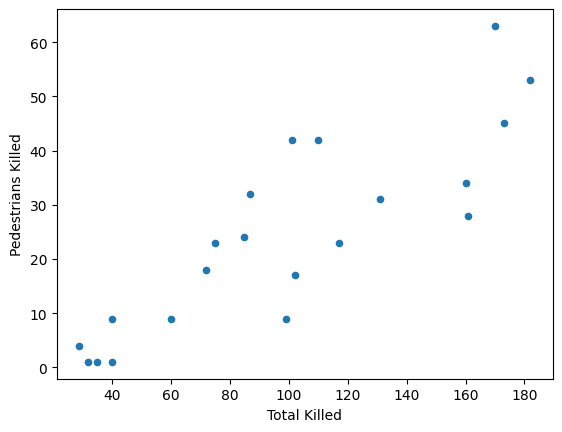

In [156]:
county_crash_scatter[["Total Killed", "Pedestrians Killed"]].plot.scatter(x = "Total Killed", y = "Pedestrians Killed")

In [157]:
# from bokeh.plotting import figure, show, output_notebook
# output_notebook()  # important in Jupyter

# p = figure()
# p.scatter([1,2,3,4], [4,7,2,5], size=10, color="navy", alpha=0.5)  # use circle(), not scatter()
# show(p)


In [158]:
county_crash_scatter[["Total Killed", "Pedestrians Killed"]]

,Total Killed,Pedestrians Killed
0,117,23
1,101,42
2,161,28
3,173,45
4,32,1
5,99,9
6,170,63
7,102,17
8,87,32
9,40,9


In [159]:
county_crash_scatter["Total Killed"].isnull().sum()

np.int64(0)

In [160]:
# %pip install seaborn

In [161]:
import seaborn as sns

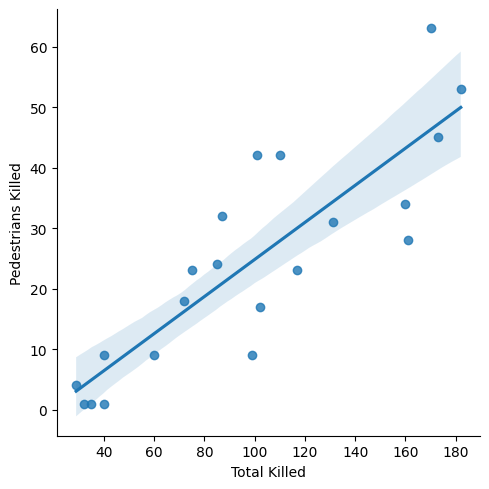

In [162]:
sns.lmplot(x = "Total Killed",
           y = "Pedestrians Killed",
           data = county_crash_scatter)

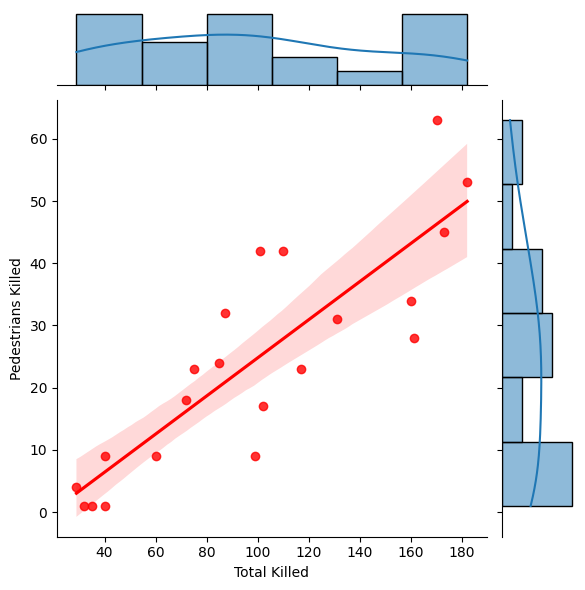

In [163]:
import matplotlib.pyplot as plt

sns.jointplot(x = "Total Killed",
              y = "Pedestrians Killed",
              data = county_crash_scatter,
              kind = "reg",
              joint_kws = {"color":"red"})

### `Line Chart`

> Let's see the number of New Jersey car crashes over time (2008-2013)

In [164]:
crash_by_date_line

,Crash Date,County Name
0,2008-01-01,575
1,2008-01-02,716
2,2008-01-03,830
3,2008-01-04,906
4,2008-01-05,674
...,...,...
1456,2011-12-27,589
1457,2011-12-28,369
1458,2011-12-29,429
1459,2011-12-30,483


In [165]:
crash_by_date_line["Crash Date"] = pd.to_datetime(crash_by_date_line["Crash Date"])
crash_by_date_line

,Crash Date,County Name
0,2008-01-01,575
1,2008-01-02,716
2,2008-01-03,830
3,2008-01-04,906
4,2008-01-05,674
...,...,...
1456,2011-12-27,589
1457,2011-12-28,369
1458,2011-12-29,429
1459,2011-12-30,483


In [166]:
# line = figure(title = "The Number of New Jersey Car Crashes Over Time (2008-2013)",
#               x_axis_type = "datetime",
#               plot_width = 800,
#               plot_height = 600)

# line.line(crash_by_date_line["Crash Date"],
#           crash_by_date_line["County Name"],
#           line_width = 1,
#           line_color = "purple")

# line.yaxis.axis_label = "County Name"
# line.xaxis.axis_label = "Crash Date"
# line.xaxis.major_label_orientation = "vertical"

# output_file("line_timeseries.html")
# show(line)


In [167]:
crash_by_date_line

,Crash Date,County Name
0,2008-01-01,575
1,2008-01-02,716
2,2008-01-03,830
3,2008-01-04,906
4,2008-01-05,674
...,...,...
1456,2011-12-27,589
1457,2011-12-28,369
1458,2011-12-29,429
1459,2011-12-30,483


In [170]:
crash_by_date_line

,Crash Date,County Name
0,2008-01-01,575
1,2008-01-02,716
2,2008-01-03,830
3,2008-01-04,906
4,2008-01-05,674
...,...,...
1456,2011-12-27,589
1457,2011-12-28,369
1458,2011-12-29,429
1459,2011-12-30,483


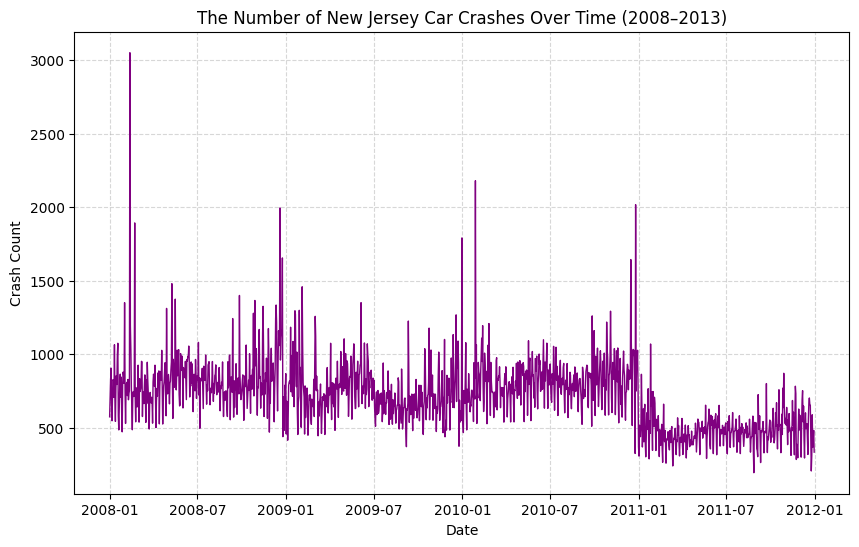

In [171]:
import matplotlib.pyplot as plt

# Assuming crash_by_date_line is grouped already
# e.g. crash_by_date_line = crash_info.groupby("Crash Date").size().reset_index(name="Crash Count")

plt.figure(figsize=(10,6))
plt.plot(crash_by_date_line["Crash Date"], crash_by_date_line["County Name"], color="purple", linewidth=1)

plt.title("The Number of New Jersey Car Crashes Over Time (2008–2013)")
plt.xlabel("Date")
plt.ylabel("Crash Count")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


> `Thank you for working with the script :)`